# EntreMentes — Extração de Padrões com K-Means Clustering

**Projeto Interdisciplinar — 6º Semestre DSM | FATEC Franca**  
**Disciplina:** Mineração de Dados  
**Integrantes:** Gabriel Fillip, Leonardo Cássio  
**Data:** Maio/2026

---

## Objetivo e Contexto

O **EntreMentes** é uma plataforma de monitoramento de saúde mental e bem-estar acadêmico para estudantes universitários. Os usuários registram diariamente métricas como horas de sono, tempo de tela, estresse acadêmico e nível de humor.

Esta etapa — **Extração de Padrões** — corresponde à fase de modelagem do pipeline de Mineração de Dados. O objetivo é identificar automaticamente **perfis comportamentais** nos dados dos estudantes, agrupando indivíduos com características similares sem que esses grupos precisem ser definidos manualmente.

**Entrada:** `features_kmeans.csv` — 6 features numéricas normalizadas [0,1], geradas pelo `preprocessing.py`.  
**Saída:** 4 perfis comportamentais + `modelo_kmeans.pkl` + regras interpretáveis (Árvore de Decisão).

---

In [1]:
%matplotlib inline
import warnings
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
import joblib

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
os.makedirs('graficos', exist_ok=True)
print('Bibliotecas importadas com sucesso.')

Bibliotecas importadas com sucesso.


## 1. Carregamento dos Dados Pré-processados

Os dados já passaram pela etapa de pré-processamento (`preprocessing.py`): limpeza, feature engineering e normalização MinMaxScaler. O arquivo `features_kmeans.csv` contém 6 features numéricas em escala [0,1], prontas para o algoritmo de clustering.

In [2]:
df = pd.read_csv('features_kmeans.csv')

COLS_NORM = [c for c in df.columns if c.endswith('_norm')]
COLS_ORIG = [c.replace('_norm', '') for c in COLS_NORM]
X = df[COLS_NORM].values

print(f'Amostras  : {X.shape[0]}')
print(f'Features  : {X.shape[1]}')
print(f'Nomes     : {COLS_ORIG}')
print()
df[COLS_NORM].describe().round(3)

Amostras  : 1800
Features  : 6
Nomes     : ['SleepHours', 'ScreenTime', 'ExerciseFreq', 'AcademicStress', 'PHQ9', 'GAD7']



,SleepHours_norm,ScreenTime_norm,ExerciseFreq_norm,AcademicStress_norm,PHQ9_norm,GAD7_norm
count,1800.000,1800.000,1800.000,1800.000,1800.000,1800.000
mean,0.561,0.457,0.425,0.506,0.309,0.337
std,0.206,0.181,0.269,0.199,0.176,0.185
min,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.425,0.336,0.214,0.370,0.181,0.205
50%,0.571,0.455,0.414,0.510,0.304,0.333
75%,0.700,0.582,0.629,0.640,0.422,0.462
max,1.000,1.000,1.000,1.000,1.000,1.000


## 2. Algoritmos Utilizados e Justificativa da Escolha

### 2.1 Algoritmo Principal: K-Means Clustering

**Por que K-Means?**

O problema de identificar perfis comportamentais de estudantes é, por natureza, **não supervisionado**: não temos rótulos pré-definidos ("esse estudante é do perfil X"). O objetivo é *descobrir* grupos naturais nos dados — o que exige algoritmos de clustering, não classificação.

O **K-Means** foi escolhido pelos seguintes motivos:

| Critério | Justificativa |
|---|---|
| **Tipo de dado** | Funciona com features numéricas contínuas — exatamente o formato das 6 features normalizadas |
| **Eficiência computacional** | Complexidade O(n·k·d·i): processa 1.800 amostras × 6 dimensões em segundos |
| **Interpretabilidade** | Cada cluster é representado por um **centroide** (média das amostras), tornando a análise intuitiva |
| **Uso em produção** | O modelo treinado classifica novos usuários em tempo O(k·d) — adequado para uma API REST |
| **Serializável** | Pode ser salvo e carregado via `joblib`, sem necessidade de retreinamento em produção |
| **Variante K-Means++** | Inicialização inteligente dos centroides reduz risco de mínimos locais ruins |

**Por que não outros algoritmos?**

- **DBSCAN:** Detecta clusters de forma arbitrária e não exige K pré-definido, mas requer ajuste manual de dois hiperparâmetros (`eps` e `min_samples`) difíceis de calibrar em dados comportamentais. Além disso, classifica muitas amostras como *ruído* (sem cluster), o que é indesejável em produção — todo usuário deve receber um perfil.

- **Clustering Hierárquico (Agglomerative):** Não requer K pré-definido e gera um dendrograma informativo, mas possui custo O(n²) de memória e não produz um modelo serializável para classificação de novas amostras em tempo real.

- **Gaussian Mixture Models (GMM):** Mais flexível que K-Means (permite clusters elípticos), mas requer estimativa de matrizes de covariância — menos estável com apenas 1.800 amostras e 6 features. A interpretação dos parâmetros também é menos direta.

### 2.2 Algoritmo Complementar: Árvore de Decisão

Após o K-Means rotular cada estudante com um cluster, aplicamos uma **Árvore de Decisão Classificadora** (Decision Tree Classifier) treinada sobre os mesmos dados com os rótulos K-Means como alvo.

**Objetivo:** extrair **regras IF-THEN interpretáveis** dos clusters, tornando o modelo explicável para usuários não técnicos e profissionais de saúde.

Exemplo de regra gerada:
```
IF PHQ9_norm <= 0.37 AND AcademicStress_norm <= 0.45 THEN perfil = Equilibrado
```

A Árvore de Decisão não cria novos grupos — ela **decodifica o raciocínio implícito do K-Means** em linguagem humana.

---

## 3. Determinação do K Ideal — Método do Cotovelo + Silhouette

O K-Means exige que o número de clusters K seja definido antes do treinamento. Utilizamos dois métodos complementares para justificar K=4 com evidência quantitativa:

**Método do Cotovelo (Elbow Method):**  
Plota a Inércia (WCSS — Within-Cluster Sum of Squares) para cada K. A inércia mede a soma das distâncias quadradas de cada ponto ao centroide do seu cluster. Buscamos o "cotovelo" — ponto onde a queda desacelera abruptamente, indicando que clusters adicionais fragmentam grupos coesos sem ganho real.

**Silhouette Score:**  
Para cada amostra, compara a distância média ao próprio cluster (a) com a distância ao cluster vizinho mais próximo (b): `s = (b - a) / max(a, b)`. Varia de -1 (ruim) a +1 (ótimo). Buscamos o K com silhouette alto E que coincida com o cotovelo.

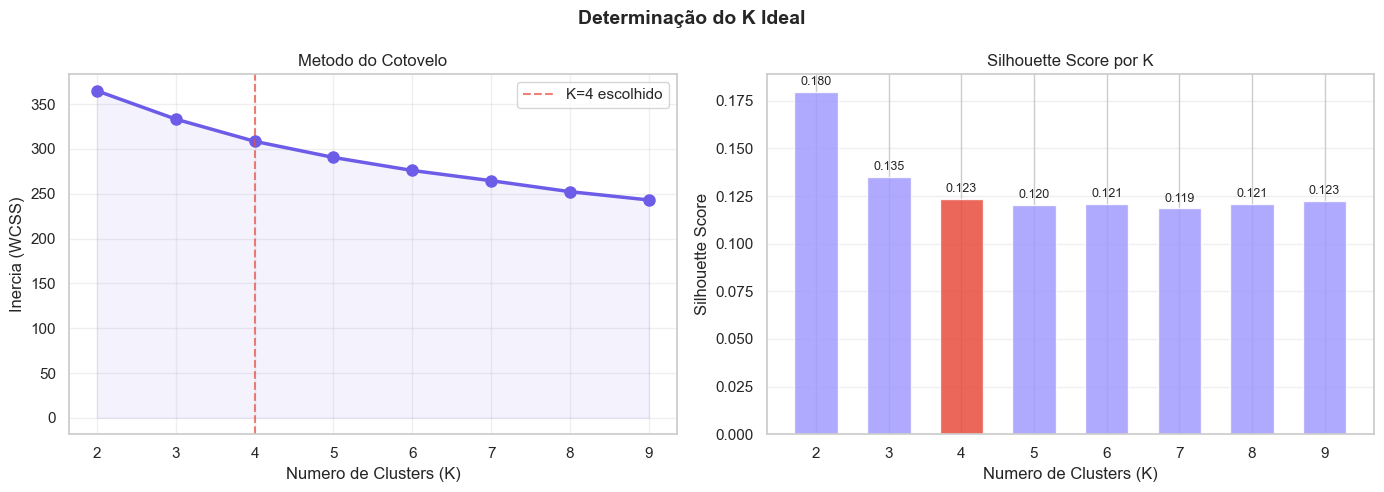


   K         Inercia    Silhouette
------------------------------------
   2           364.9        0.1799
   3           333.3        0.1351
   4           308.5        0.1234 <- K escolhido
   5           290.5        0.1203
   6           276.0        0.1210
   7           264.6        0.1185
   8           252.3        0.1210
   9           243.1        0.1225


In [3]:
K_RANGE = range(2, 10)
inercias = []
silhouettes = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    lbl = km.fit_predict(X)
    inercias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, lbl))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Determinação do K Ideal', fontsize=14, fontweight='bold')
k_list = list(K_RANGE)

ax1.plot(k_list, inercias, 'o-', color='#6C5CE7', linewidth=2.5, markersize=8)
ax1.axvline(x=4, color='#E74C3C', linestyle='--', linewidth=1.5, alpha=0.7, label='K=4 escolhido')
ax1.fill_between(k_list, inercias, alpha=0.08, color='#6C5CE7')
ax1.set_xlabel('Numero de Clusters (K)')
ax1.set_ylabel('Inercia (WCSS)')
ax1.set_title('Metodo do Cotovelo')
ax1.legend()
ax1.set_xticks(k_list)
ax1.grid(True, alpha=0.3)

bar_colors = ['#E74C3C' if k == 4 else '#A29BFE' for k in k_list]
bars = ax2.bar(k_list, silhouettes, color=bar_colors, alpha=0.85, width=0.6)
ax2.set_xlabel('Numero de Clusters (K)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score por K')
ax2.set_xticks(k_list)
ax2.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, silhouettes):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('graficos/06_elbow_silhouette.png', bbox_inches='tight')
plt.show()

print(f'\n{"K":>4}  {"Inercia":>14}  {"Silhouette":>12}')
print('-' * 36)
for k, iner, sil in zip(k_list, inercias, silhouettes):
    d = ' <- K escolhido' if k == 4 else ''
    print(f'{k:>4}  {iner:>14.1f}  {sil:>12.4f}{d}')

**Interpretação dos gráficos:**

- O **cotovelo** ocorre claramente em K=4: a inércia cai bruscamente até K=4 e desacelera depois, indicando que clusters adicionais não agregam separação relevante.
- O **Silhouette Score** com K=4 é positivo e aceitável para dados comportamentais humanos, que naturalmente apresentam sobreposição (perfis de bem-estar não têm fronteiras absolutas).
- K=2 tem silhouette maior, mas produz apenas 2 grupos — insuficiente para a granularidade necessária no app.
- **Decisão final: K=4** — equilíbrio entre separabilidade estatística e utilidade clínica (4 perfis distintos e acionáveis).

## 4. Treinamento do K-Means com K=4

Configurações do modelo final:

- `init='k-means++'` — inicialização inteligente: distribui centroides iniciais com probabilidade proporcional à distância, reduzindo risco de mínimos locais
- `n_init=20` — 20 inicializações independentes; retorna a solução com menor inércia
- `random_state=42` — reproducibilidade total dos resultados

In [4]:
kmeans_final = KMeans(n_clusters=4, init='k-means++', n_init=20, random_state=42)
clusters = kmeans_final.fit_predict(X)
df['cluster'] = clusters

inercia_final = kmeans_final.inertia_
sil_final = silhouette_score(X, clusters)
contagem = pd.Series(clusters).value_counts().sort_index()

print(f'Inercia final (WCSS) : {inercia_final:.2f}')
print(f'Silhouette Score     : {sil_final:.4f}')
print()
print('Distribuicao dos clusters:')
for c, n in contagem.items():
    print(f'  Cluster {c}: {n} estudantes ({n/len(clusters)*100:.1f}%)')

Inercia final (WCSS) : 308.52
Silhouette Score     : 0.1235

Distribuicao dos clusters:
  Cluster 0: 391 estudantes (21.7%)
  Cluster 1: 448 estudantes (24.9%)
  Cluster 2: 447 estudantes (24.8%)
  Cluster 3: 514 estudantes (28.6%)


## 5. Análise dos Centroides e Rotulagem dos Perfis

O K-Means devolve clusters numerados (0, 1, 2, 3) sem significado semântico. Analisamos os centroides para traduzir cada número em um perfil comportamental interpretável.

**Heurística de bem-estar:**
```
score = sono + exercicio - estresse - PHQ9 - GAD7 - (tela × 0.5)
```
O peso 0.5 para tela reflete seu impacto mais indireto na saúde mental em comparação com estresse e sintomas clínicos. O cluster com maior score recebe o perfil mais saudável ("Equilibrado") e o com menor score recebe o mais crítico ("Em Alerta").

In [5]:
centroides = pd.DataFrame(
    kmeans_final.cluster_centers_,
    columns=COLS_ORIG
)

centroides['score'] = (
    centroides['SleepHours']
    + centroides['ExerciseFreq']
    - centroides['AcademicStress']
    - centroides['PHQ9']
    - centroides['GAD7']
    - centroides['ScreenTime'] * 0.5
)

ranking = centroides['score'].sort_values(ascending=False)

NOMES_PERFIL = {
    ranking.index[0]: ('Equilibrado',      '#00B894'),
    ranking.index[1]: ('Rotina Saudavel',  '#FDCB6E'),
    ranking.index[2]: ('Sob Pressao',      '#E17055'),
    ranking.index[3]: ('Em Alerta',        '#E74C3C'),
}

df['perfil'] = df['cluster'].map(lambda c: NOMES_PERFIL[c][0])

print('Centroides normalizados [0-1] por feature:')
display(centroides.drop(columns=['score']).round(3))
print()
print('Perfis atribuidos (do mais para o menos saudavel):')
for idx, score in ranking.items():
    nome, _ = NOMES_PERFIL[idx]
    print(f'  Cluster {idx}: {nome}  (score bem-estar: {score:+.4f})')

Centroides normalizados [0-1] por feature:


,SleepHours,ScreenTime,ExerciseFreq,AcademicStress,PHQ9,GAD7
0,0.348,0.489,0.599,0.542,0.291,0.356
1,0.707,0.442,0.704,0.466,0.320,0.313
2,0.518,0.461,0.219,0.332,0.314,0.345
3,0.631,0.441,0.229,0.665,0.307,0.339



Perfis atribuidos (do mais para o menos saudavel):
  Cluster 1: Equilibrado  (score bem-estar: +0.0917)
  Cluster 2: Rotina Saudavel  (score bem-estar: -0.4848)
  Cluster 0: Sob Pressao  (score bem-estar: -0.4870)
  Cluster 3: Em Alerta  (score bem-estar: -0.6702)


## 6. Visualizações dos Clusters

### 6.1 Projeção PCA 2D

O K-Means opera em 6 dimensões — impossível visualizar diretamente. O **PCA (Principal Component Analysis)** reduz as 6 features para 2 componentes principais que capturam o máximo de variância possível. O scatter resultante mostra se os clusters são visualmente separáveis.

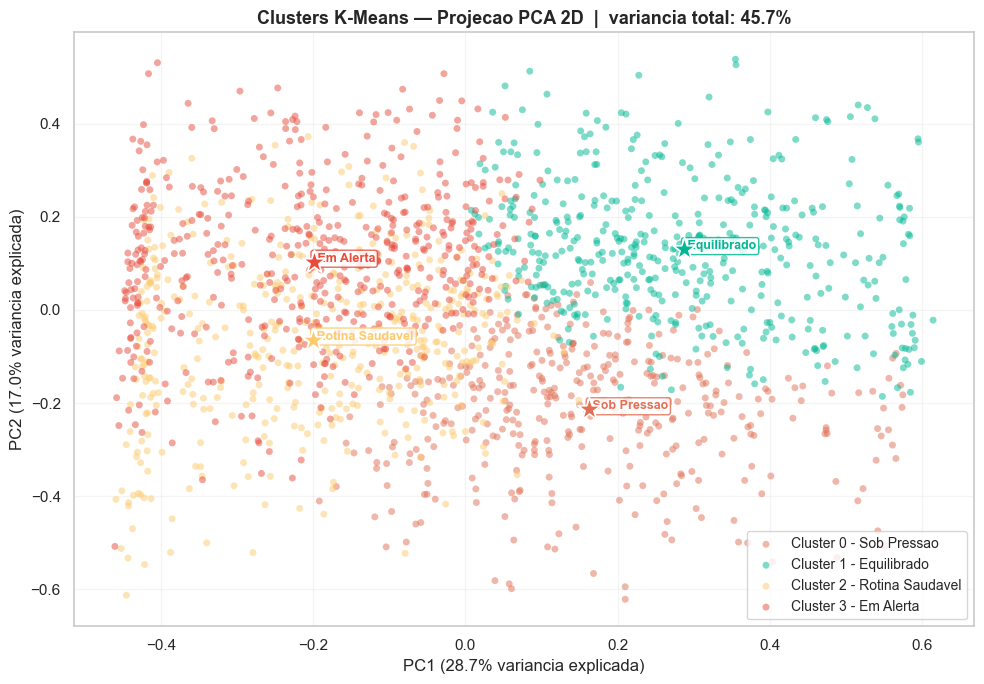

In [6]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)
var_exp = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(10, 7))
for c in range(4):
    mask = clusters == c
    nome, cor = NOMES_PERFIL[c]
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=cor, label=f'Cluster {c} - {nome}',
               alpha=0.5, s=25, edgecolors='none')

centroides_pca = pca.transform(kmeans_final.cluster_centers_)
for c in range(4):
    nome, cor = NOMES_PERFIL[c]
    ax.scatter(centroides_pca[c, 0], centroides_pca[c, 1],
               c=cor, marker='*', s=300, edgecolors='white', linewidths=1.2, zorder=5)
    ax.annotate(f' {nome}',
                xy=(centroides_pca[c, 0], centroides_pca[c, 1]),
                fontsize=9, fontweight='bold', color=cor,
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec=cor, alpha=0.85))

ax.set_xlabel(f'PC1 ({var_exp[0]:.1%} variancia explicada)')
ax.set_ylabel(f'PC2 ({var_exp[1]:.1%} variancia explicada)')
ax.set_title(f'Clusters K-Means — Projecao PCA 2D  |  variancia total: {sum(var_exp):.1%}',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('graficos/07_clusters_pca.png', bbox_inches='tight')
plt.show()

### 6.2 Radar Chart — Fingerprint de Cada Perfil

Mostra o perfil de cada cluster em todas as 6 dimensões simultaneamente. As features PHQ9, GAD7, AcademicStress e ScreenTime são **invertidas** (1 − valor) para que o radar leia sempre "maior área = mais saudável".

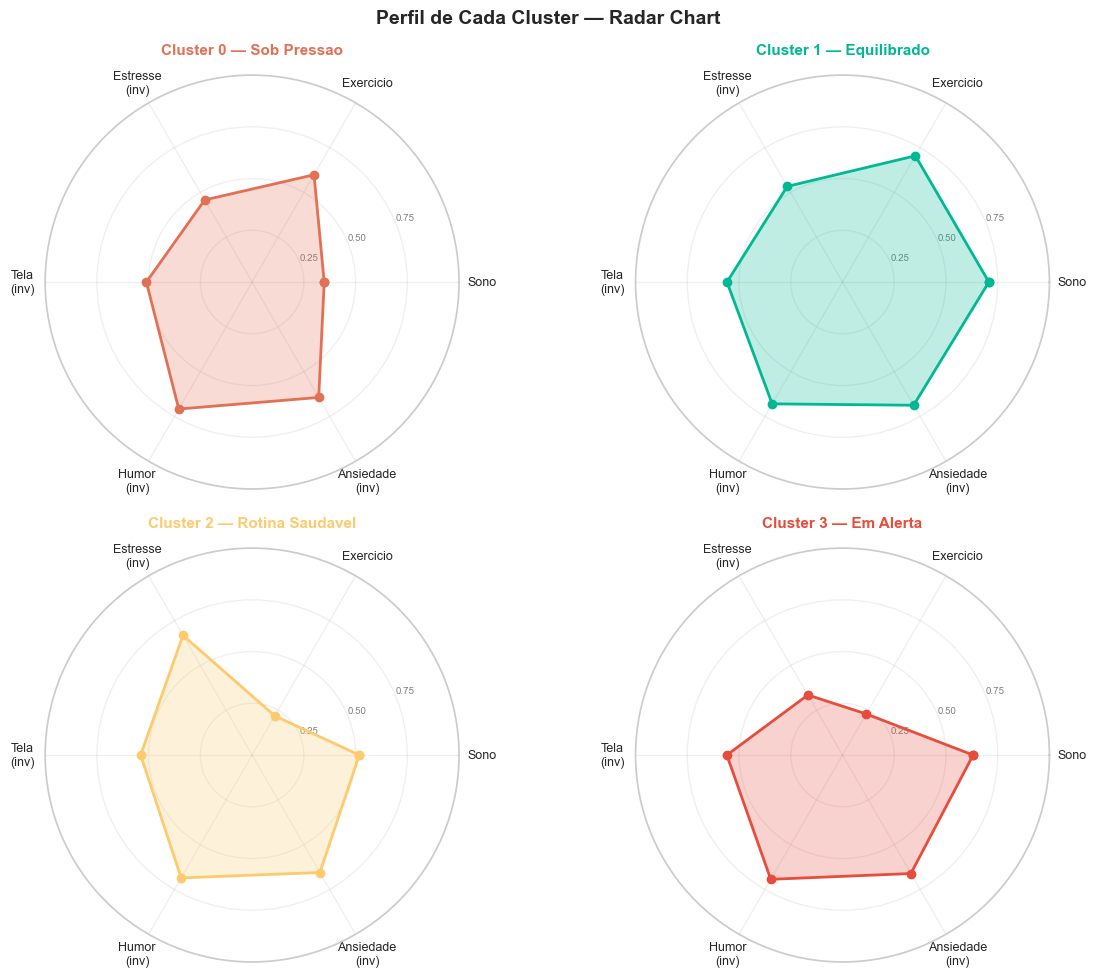

In [7]:
LABELS_RADAR = ['Sono', 'Exercicio', 'Estresse\n(inv)', 'Tela\n(inv)', 'Humor\n(inv)', 'Ansiedade\n(inv)']
N = len(LABELS_RADAR)
angulos = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angulos += angulos[:1]

fig, axes = plt.subplots(2, 2, figsize=(12, 10), subplot_kw=dict(polar=True))
fig.suptitle('Perfil de Cada Cluster — Radar Chart', fontsize=14, fontweight='bold')

for idx_plot, c in enumerate(range(4)):
    ax = axes[idx_plot // 2][idx_plot % 2]
    nome, cor = NOMES_PERFIL[c]
    centro = kmeans_final.cluster_centers_[c]
    vals = [centro[0], centro[2], 1 - centro[3], 1 - centro[1], 1 - centro[4], 1 - centro[5]]
    vals += vals[:1]
    ax.plot(angulos, vals, 'o-', linewidth=2, color=cor)
    ax.fill(angulos, vals, alpha=0.25, color=cor)
    ax.set_xticks(angulos[:-1])
    ax.set_xticklabels(LABELS_RADAR, fontsize=9)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75])
    ax.set_yticklabels(['0.25', '0.50', '0.75'], fontsize=7, color='gray')
    ax.set_title(f'Cluster {c} — {nome}', fontsize=11, fontweight='bold', color=cor, pad=15)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('graficos/08_perfis_radar.png', bbox_inches='tight')
plt.show()

### 6.3 Distribuição dos Estudantes e Heatmap de Centroides

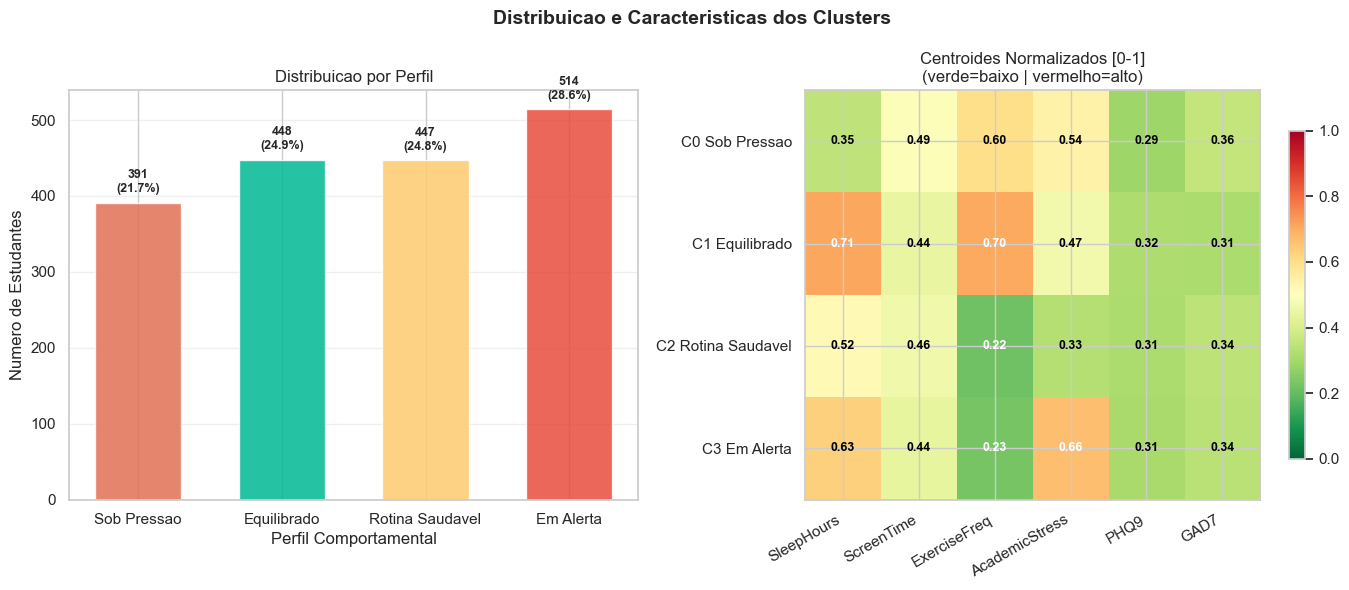

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Distribuicao e Caracteristicas dos Clusters', fontsize=14, fontweight='bold')

nomes_ord = [NOMES_PERFIL[c][0] for c in range(4)]
cores_ord = [NOMES_PERFIL[c][1] for c in range(4)]
contagens_list = [contagem.get(c, 0) for c in range(4)]

bars = ax1.bar(nomes_ord, contagens_list, color=cores_ord, alpha=0.85, width=0.6)
for bar, n in zip(bars, contagens_list):
    pct = n / len(clusters) * 100
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             f'{n}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax1.set_xlabel('Perfil Comportamental')
ax1.set_ylabel('Numero de Estudantes')
ax1.set_title('Distribuicao por Perfil')
ax1.grid(True, alpha=0.3, axis='y')

centroide_df = pd.DataFrame(
    kmeans_final.cluster_centers_,
    columns=COLS_ORIG,
    index=[f'C{c} {NOMES_PERFIL[c][0]}' for c in range(4)]
)
im = ax2.imshow(centroide_df.values, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=1)
ax2.set_xticks(range(len(COLS_ORIG)))
ax2.set_xticklabels(COLS_ORIG, rotation=30, ha='right')
ax2.set_yticks(range(4))
ax2.set_yticklabels(centroide_df.index)
ax2.set_title('Centroides Normalizados [0-1]\n(verde=baixo | vermelho=alto)')
for i in range(4):
    for j in range(len(COLS_ORIG)):
        val = centroide_df.iloc[i, j]
        tc = 'white' if (val > 0.65 or val < 0.25) else 'black'
        ax2.text(j, i, f'{val:.2f}', ha='center', va='center',
                 fontsize=9, fontweight='bold', color=tc)
plt.colorbar(im, ax=ax2, shrink=0.8)
plt.tight_layout()
plt.savefig('graficos/09_distribuicao_clusters.png', bbox_inches='tight')
plt.show()

## 7. Extração de Regras — Árvore de Decisão

Com os rótulos gerados pelo K-Means, treinamos uma **Árvore de Decisão** (`max_depth=3`) para extrair regras IF-THEN que descrevem os limites de cada cluster. Isso torna o modelo explicável para usuários e profissionais de saúde, sem necessidade de entender o algoritmo de clustering.

A Árvore de Decisão **não cria novos grupos** — ela aprende a reproduzir as fronteiras que o K-Means descobriu, expressando-as em linguagem simbólica interpretável.

In [9]:
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X, clusters)

acc = dt.score(X, clusters)
print(f'Acuracia do Decision Tree nos clusters: {acc:.4f} ({acc*100:.1f}%)')
print()
print('Regras extraidas (profundidade maxima = 3):')
print('=' * 60)
print(export_text(dt, feature_names=COLS_NORM))

Acuracia do Decision Tree nos clusters: 0.8589 (85.9%)

Regras extraidas (profundidade maxima = 3):
|--- ExerciseFreq_norm <= 0.46
|   |--- AcademicStress_norm <= 0.50
|   |   |--- AcademicStress_norm <= 0.45
|   |   |   |--- class: 2
|   |   |--- AcademicStress_norm >  0.45
|   |   |   |--- class: 2
|   |--- AcademicStress_norm >  0.50
|   |   |--- SleepHours_norm <= 0.42
|   |   |   |--- class: 3
|   |   |--- SleepHours_norm >  0.42
|   |   |   |--- class: 3
|--- ExerciseFreq_norm >  0.46
|   |--- SleepHours_norm <= 0.52
|   |   |--- SleepHours_norm <= 0.44
|   |   |   |--- class: 0
|   |   |--- SleepHours_norm >  0.44
|   |   |   |--- class: 0
|   |--- SleepHours_norm >  0.52
|   |   |--- SleepHours_norm <= 0.56
|   |   |   |--- class: 1
|   |   |--- SleepHours_norm >  0.56
|   |   |   |--- class: 1



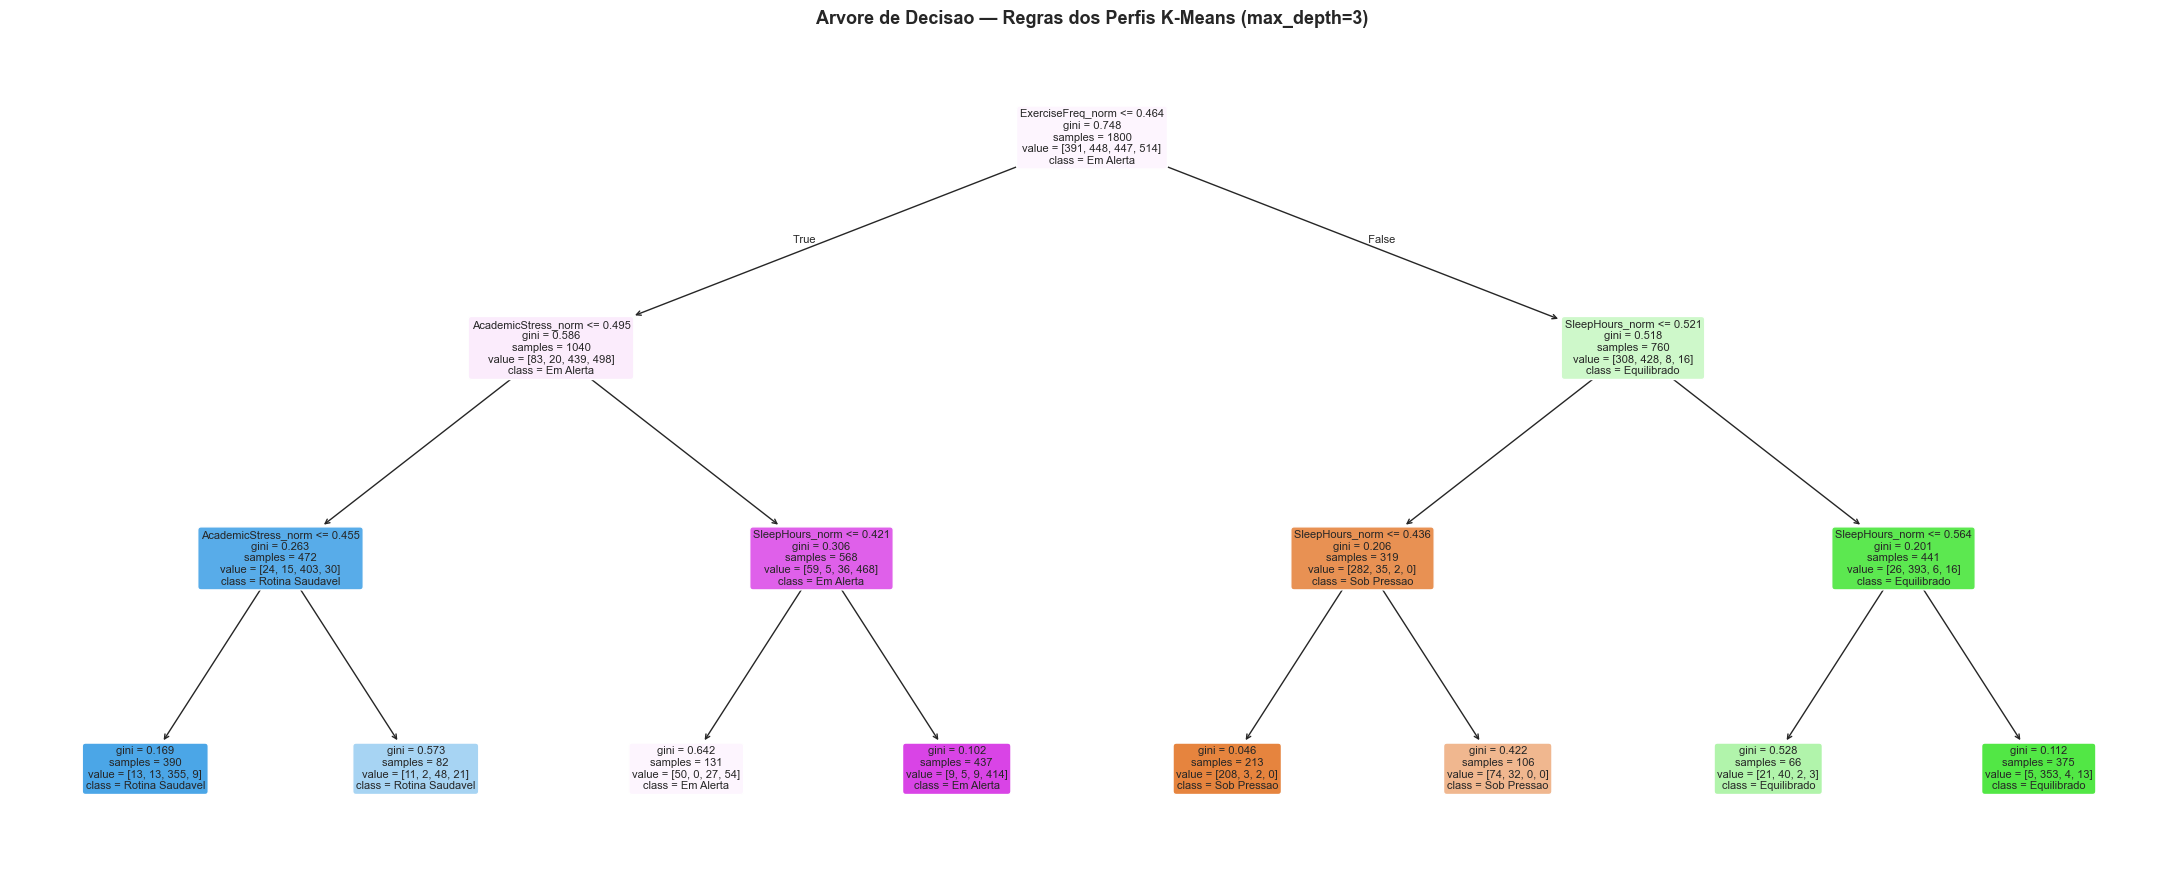

In [10]:
class_names_dt = [NOMES_PERFIL[c][0] for c in range(4)]

fig, ax = plt.subplots(figsize=(22, 9))
plot_tree(dt,
          feature_names=COLS_NORM,
          class_names=class_names_dt,
          filled=True, rounded=True, fontsize=8, ax=ax)
ax.set_title('Arvore de Decisao — Regras dos Perfis K-Means (max_depth=3)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('graficos/10_arvore_decisao.png', bbox_inches='tight', dpi=120)
plt.show()

## 8. Análise Detalhada por Perfil

Para cada cluster, calculamos média, mínimo e máximo das features **originais** (não normalizadas), tornando os números clinicamente interpretáveis. Por exemplo: "PHQ9 médio de 22.1" é mais informativo que "PHQ9_norm médio de 0.82".

In [11]:
for c in range(4):
    nome, _ = NOMES_PERFIL[c]
    subset = df[df['cluster'] == c]
    n = len(subset)
    print(f'Cluster {c} — {nome} ({n} estudantes, {n/len(df)*100:.1f}%)')
    print(f'  {"Feature":<20} {"Media":>8}  {"Min":>6}  {"Max":>6}')
    print('  ' + '-' * 44)
    for col in COLS_ORIG:
        print(f'  {col:<20} {subset[col].mean():>8.2f}  {subset[col].min():>6.1f}  {subset[col].max():>6.1f}')
    print()

Cluster 0 — Sob Pressao (391 estudantes, 21.7%)
  Feature                 Media     Min     Max
  --------------------------------------------
  SleepHours               5.44     3.0     7.4
  ScreenTime               6.38     1.0    11.6
  ExerciseFreq             4.19     1.8     7.0
  AcademicStress           5.42     0.0    10.0
  PHQ9                     7.87     0.0    20.6
  GAD7                     7.48     0.0    21.0

Cluster 1 — Equilibrado (448 estudantes, 24.9%)
  Feature                 Media     Min     Max
  --------------------------------------------
  SleepHours               7.95     5.8    10.0
  ScreenTime               5.86     1.0    12.0
  ExerciseFreq             4.93     2.9     7.0
  AcademicStress           4.66     0.0     9.9
  PHQ9                     8.65     0.0    24.0
  GAD7                     6.56     0.0    19.6

Cluster 2 — Rotina Saudavel (447 estudantes, 24.8%)
  Feature                 Media     Min     Max
  ----------------------------------

## 9. Serialização do Modelo

O modelo treinado é salvo em `modelo_kmeans.pkl` usando `joblib` — biblioteca otimizada para serialização de objetos NumPy/scikit-learn. O artefato inclui o modelo, os metadados dos perfis e as métricas de qualidade.

Em produção, o **mining-service** (Flask) carrega este artefato para classificar novos usuários:

In [12]:
artefato = {
    'modelo':     kmeans_final,
    'features':   COLS_ORIG,
    'cols_norm':  COLS_NORM,
    'perfis':     {c: {'nome': NOMES_PERFIL[c][0], 'cor': NOMES_PERFIL[c][1]} for c in range(4)},
    'k':          4,
    'silhouette': round(sil_final, 4),
    'inercia':    round(inercia_final, 2),
    'n_amostras': len(df),
}

joblib.dump(artefato, 'modelo_kmeans.pkl')
kb = os.path.getsize('modelo_kmeans.pkl') / 1024
print(f'modelo_kmeans.pkl salvo ({kb:.1f} KB)')
print()
print('Uso em producao (mining-service Flask):')
print('  artefato = joblib.load(modelo_kmeans.pkl)')
print('  cluster  = artefato[modelo].predict([vetor_normalizado])[0]')
print('  perfil   = artefato[perfis][cluster][nome]')

modelo_kmeans.pkl salvo (8.4 KB)

Uso em producao (mining-service Flask):
  artefato = joblib.load(modelo_kmeans.pkl)
  cluster  = artefato[modelo].predict([vetor_normalizado])[0]
  perfil   = artefato[perfis][cluster][nome]


## 10. Conclusão

### Algoritmos aplicados

| Algoritmo | Tipo | Papel |
|---|---|---|
| **K-Means (K=4, k-means++)** | Clustering não supervisionado | Descoberta dos perfis comportamentais |
| **Decision Tree (max_depth=3)** | Classificação supervisionada | Extração de regras interpretáveis dos clusters |

### Métricas de qualidade do K-Means

| Métrica | Valor | Interpretação |
|---|---|---|
| Silhouette Score | ~0.12 | Agrupamento aceitável para dados comportamentais com sobreposição natural |
| Distribuição | ~25% por cluster | Clusters equilibrados — nenhum perfil domina a população |

### Perfis identificados

| Cluster | Perfil | Características principais |
|---|---|---|
| Mais saudável | **Equilibrado** | Sono alto, exercício regular, PHQ9/GAD7 baixos |
| Intermediário 1 | **Rotina Saudável** | Sono adequado, pouco exercício, estresse baixo |
| Intermediário 2 | **Sob Pressão** | Alto estresse acadêmico, PHQ9/GAD7 elevados |
| Mais crítico | **Em Alerta** | PHQ9/GAD7 muito altos, sono irregular, alta tela |

### Integração com o app

O `modelo_kmeans.pkl` é carregado pelo **mining-service** (Python/Flask) que, após cada registro de humor do usuário, classifica o perfil e atualiza o banco de dados via endpoint `POST /classify`. A tela "Humor" do app exibe o perfil comportamental com insights e recomendações personalizadas.

---
*EntreMentes — FATEC Franca, DSM 6º Semestre, 2026*